In [40]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from astropy.table import Column
from scipy.stats import bootstrap

### Creating File (once)

In [2]:
fits_name = 'modulus_tracker_cepheids.fits'
fits_name = 'modulus_tracker_trgb.fits'
fits_name = 'modulus_tracker.fits'

#Making primary

rands_x1hdu = np.random.random((1,1))
primary_hdu = fits.PrimaryHDU(data=rands_x1hdu)

HDU = fits.HDUList([primary_hdu])



#hosts_old = ['LMC','IC0010','IC2574','MESSIER033','MESSIER081','MESSIER101','MRK0116','NGC0925','NGC2366',
#         'NGC2403','NGC2541','NGC3198','NGC3319','MESSIER106','NGC4395','NGC6822','NGC1073',
#         'NGC2500','NGC3184','MESSIER096','NGC3370','MESSIER066','NGC4214','NGC4414','NGC4496',
#         'NGC4535','NGC4536','NGC4725','UGC08091','NGC5204','UGC09128','NGC5584']

hosts = ['IC0010','IC2574','M33','M81','M101','MRK116','NGC0925','NGC2366','NGC2403','NGC2541','NGC3198'
         ,'NGC3319','NGC4214','NGC4236','NGC4258','NGC4395','NGC6822','NGC1073','NGC2500','NGC3184','M96'
         ,'NGC3370','M66','NGC4414','NGC4496','NGC4535','NGC4536','NGC4725','UGC08091','NGC5204','UGC09128'
         ,'NGC5584']


len(hosts)


def binTable_creator(host,mode='C'):
    values = []
    HDR = fits.Header()
    if mode=='C':
        refcode = Column(values, name='RefCode', description="Article's RefCode", dtype='S40')
        citation = Column(values, name='Citation', description="Article's Citation", dtype='S40')
        band = Column(values, name='Band', description='Band', dtype='S40')
        modulus = Column(values, name='mu_0', description="Distance modulus", dtype='float64')
        err_rand = Column(values, name='e_R', description='Random error', dtype='float64')
        err_sys = Column(values, name='e_S', description='Sytematic error', dtype='float64')
        err_tot = Column(values, name='e_T', description='Total error', dtype='float64')
        category = Column(values, name='Category', description='Quality of observation given error', dtype='int64')
        Ncef = Column(values, name='Ncef', description='Number of cepheids reported', dtype='int64')
        Zcorr = Column(values, name='Zcorr', description='Metallicity correction', dtype='bool')
        zeroP = Column(values, name='zeroP', description='Zero-Point calibration', dtype='S20')
        rank = Column(values, name='Rank', description='Observation type (rank)', dtype='int64')
        year = Column(values, name='Year', description='Year of the publication', dtype='int64')
        date = Column(values, name='Date', description='Data entry date', dtype='S12')
        comments = Column(values, name='Comments', description='Commentary', dtype='S800')
        author = Column(values, name='Author', description='Author responsible for this research', dtype='S50')
        

        T = Table([refcode, citation, band, modulus, err_rand, err_sys,err_tot,category,Ncef,Zcorr,zeroP,rank,year,date,comments,author])
        HDR.insert(0,('METHOD', 'CEPHEIDS', 'Cepheids PLR method'))

        hdu = fits.BinTableHDU(data = T,
                header=HDR,
                name = host)
        
        hdu_head = hdu.header
        hdu_head.set('EXTNAME', host, "Name of Host Galaxy")
        hdu_head.set('TTYPE1', 'RefCode', T['RefCode'].description)
        hdu_head.set('TTYPE2', 'Citation', T['Citation'].description)
        hdu_head.set('TTYPE3', 'Band', T['Band'].description)
        hdu_head.set('TTYPE4', 'mu_0', T['mu_0'].description)
        hdu_head.set('TTYPE5', 'e_R', T['e_R'].description)
        hdu_head.set('TTYPE6', 'e_S', T['e_S'].description)
        hdu_head.set('TTYPE7', 'e_T', T['e_T'].description)
        hdu_head.set('TTYPE8', 'Category', T['Category'].description)
        hdu_head.set('TTYPE9', 'Ncef', T['Ncef'].description)
        hdu_head.set('TTYPE10', 'Zcorr', T['Zcorr'].description)
        hdu_head.set('TTYPE11', 'zeroP', T['zeroP'].description)
        hdu_head.set('TTYPE12', 'Rank', T['Rank'].description)
        hdu_head.set('TTYPE13', 'Year', T['Year'].description)
        hdu_head.set('TTYPE14', 'Date', T['Date'].description)
        hdu_head.set('TTYPE15', 'Comments', T['Comments'].description)
        hdu_head.set('TTYPE16', 'Author', T['Author'].description)

        hdu_head.insert(42, ('COMMENT',''))
        hdu_head.insert(43, ('COMMENT',
                             'Category: (1) Explicitly random error considering purely photometric errors of all Cepheids; (2) Explicitly random and systematic error separately, the total error is calculated from equation X (mentioned in the manuscript); (3) Random error but all or most systematic errors are mentioned in the publication; (4) Total error only; (5) Random error but the distance modulus is expressed without adding the zero point. The distance modulus presented in the publication is added manually.'))
        
        hdu_head.insert(44, ('COMMENT',''))
        hdu_head.insert(45, ('COMMENT',
                             'zeroP: LMC corresponds to the Large Magellanic Cloud; GC corresponds to Galactic Cepheids; N4258 corresponds to NGC4258; TM corresponds to Theoretical Models.'))
        
        hdu_head.insert(46, ('COMMENT',''))
        hdu_head.insert(47, ('COMMENT',
                             'Rank: (1) They are space telescopes like HST, Spitzer or JWST, (2) Telescopes located at Hawai, Chile or Canary Islands (3) Any other terrestrial telescope'))
        


        return hdu
        
    if mode=='T':
        refcode = Column(values, name='RefCode', description="Article's RefCode", dtype='S40')
        citation = Column(values, name='Citation', description="Article's Citation", dtype='S40')
        band = Column(values, name='Band', description='Band', dtype='S40')
        modulus = Column(values, name='mu_0', description="Distance modulus", dtype='float64')
        err_rand = Column(values, name='e_R', description='Random error', dtype='float64')
        rank = Column(values, name='Rank', description='Observation type (rank)', dtype='int64')
        year = Column(values, name='Year', description='Year of the publication', dtype='int64')
        date = Column(values, name='Date', description='Data entry date', dtype='S12')
        comments = Column(values, name='Comments', description='Commentary', dtype='S800')
        author = Column(values, name='Author', description='Author responsible for this research', dtype='S50')

        T = Table([refcode, citation, band, modulus, err_rand,rank,year,date,comments,author])

        HDR.insert(0,('METHOD', 'TRGB', 'Tip of the Red Giant Branch method'))

        hdu = fits.BinTableHDU(data = T,
                header=HDR,
                name = host)
        
        hdu_head = hdu.header
        hdu_head.set('EXTNAME', host, "Name of Host Galaxy")
        hdu_head.set('TTYPE1', 'RefCode', T['RefCode'].description)
        hdu_head.set('TTYPE2', 'Citation', T['Citation'].description)
        hdu_head.set('TTYPE3', 'Band', T['Band'].description)
        hdu_head.set('TTYPE4', 'mu_0', T['mu_0'].description)
        hdu_head.set('TTYPE5', 'e_R', T['e_R'].description)
        hdu_head.set('TTYPE6', 'Rank', T['Rank'].description)
        hdu_head.set('TTYPE7', 'Year', T['Year'].description)
        hdu_head.set('TTYPE8', 'Date', T['Date'].description)
        hdu_head.set('TTYPE9', 'Comments', T['Comments'].description)
        hdu_head.set('TTYPE10', 'Author', T['Author'].description)

        hdu_head.insert(31, ('COMMENT',''))
        hdu_head.insert(32, ('COMMENT',
                             'Rank: (1) They are space telescopes like HST, Spitzer or JWST, (2) Telescopes located at Hawai, Chile or Canary Islands (3) Any other terrestrial telescope'))
        

        return hdu
    
lista_HDUs = [primary_hdu]

for i in range(len(hosts)):

    lista_HDUs.append(binTable_creator(hosts[i],mode='C'))

    lista_HDUs.append(binTable_creator(hosts[i],mode='T'))

len(lista_HDUs)

HDU_final = fits.HDUList(lista_HDUs)


HDU_final.writeto(fits_name, overwrite=True)

In [3]:
def header_repair(HDU,Galaxy,distance_estimator):


    header = HDU.header

    header_original = header.copy() 

    if distance_estimator=='CEPHEIDS':

        tabla_keys = list(HDU.header.keys())    

        for key, value, comment in header_original.cards:
        # Solo agrega la clave si NO está en la cabecera nueva (evita duplicar o corromper)
        # o si es un campo que queremos mantener (como COMMENT o HISTORY)
            if key not in tabla_keys or key in ('COMMENT', 'HISTORY', ''): 
                try:
                    # El método .set() permite insertar un registro en la cabecera
                    # y mantiene un orden más limpio que la asignación directa
                    HDU.header.set(key, value, comment)
                except ValueError:
                    # Esto maneja el caso de keywords repetidos como COMMENT o HISTORY
                    if key in ('COMMENT', 'HISTORY', ''):
                        HDU.header.add_record(fits.Card(key, value, comment))


        hdu_head = HDU.header
        
        hdu_head.set('EXTNAME', Galaxy, "Name of Host Galaxy", before='TTYPE1')
        hdu_head.set('METHOD', distance_estimator, 'Cepheids PLR method', before='EXTNAME')
        hdu_head.set('TTYPE1', 'RefCode', "Article's RefCode")
        hdu_head.set('TTYPE2', 'Citation', "Article's Citation")
        hdu_head.set('TTYPE3', 'Band', 'Band')
        hdu_head.set('TTYPE4', 'mu_0', "Distance modulus")
        hdu_head.set('TTYPE5', 'e_R', 'Random error')
        hdu_head.set('TTYPE6', 'e_S', 'Sytematic error')
        hdu_head.set('TTYPE7', 'e_T', 'Total error')
        hdu_head.set('TTYPE8', 'Category', 'Quality of observation given error')
        hdu_head.set('TTYPE9', 'Ncef', 'Number of cepheids reported')
        hdu_head.set('TTYPE10', 'Zcorr', 'Metallicity correction')
        hdu_head.set('TTYPE11', 'zeroP', 'Zero-Point calibration')
        hdu_head.set('TTYPE12', 'Rank','Observation type (rank)')
        hdu_head.set('TTYPE13', 'Year', 'Year of the publication')
        hdu_head.set('TTYPE14', 'Date', 'Data entry date')
        hdu_head.set('TTYPE15', 'Comments', 'Commentary')
        hdu_head.set('TTYPE16', 'Author', 'Author responsible for this research')

        hdu_head.insert(42, ('COMMENT',''))
        hdu_head.insert(43, ('COMMENT',
                             'Category: (1) Explicitly random error considering purely photometric errors of all Cepheids; (2) Explicitly random and systematic error separately, the total error is calculated from equation X (mentioned in the manuscript); (3) Random error but all or most systematic errors are mentioned in the publication; (4) Total error only; (5) Random error but the distance modulus is expressed without adding the zero point. The distance modulus presented in the publication is added manually.'))
        
        hdu_head.insert(44, ('COMMENT',''))
        hdu_head.insert(45, ('COMMENT',
                             'zeroP: LMC corresponds to the Large Magellanic Cloud; GC corresponds to Galactic Cepheids; N4258 corresponds to NGC4258; TM corresponds to Theoretical Models.'))
        
        hdu_head.insert(46, ('COMMENT',''))
        hdu_head.insert(47, ('COMMENT',
                             'Rank: (1) They are space telescopes like HST, Spitzer or JWST, (2) Telescopes located at Hawai, Chile or Canary Islands (3) Any other terrestrial telescope'))

        return HDU
    
    if distance_estimator=='TRGB':

        tabla_keys = list(HDU.header.keys())    

        for key, value, comment in header_original.cards:
        # Solo agrega la clave si NO está en la cabecera nueva (evita duplicar o corromper)
        # o si es un campo que queremos mantener (como COMMENT o HISTORY)
            if key not in tabla_keys or key in ('COMMENT', 'HISTORY', ''): 
                try:
                    # El método .set() permite insertar un registro en la cabecera
                    # y mantiene un orden más limpio que la asignación directa
                    HDU.header.set(key, value, comment)
                except ValueError:
                    # Esto maneja el caso de keywords repetidos como COMMENT o HISTORY
                    if key in ('COMMENT', 'HISTORY', ''):
                        HDU.header.add_record(fits.Card(key, value, comment))


        hdu_head = HDU.header
        
        hdu_head.set('EXTNAME', Galaxy, "Name of Host Galaxy", before='TTYPE1')
        hdu_head.set('METHOD', distance_estimator, 'Tip of the Red Giant Branch method', before='EXTNAME')
        hdu_head.set('TTYPE1', 'RefCode', "Article's RefCode")
        hdu_head.set('TTYPE2', 'Citation', "Article's Citation")
        hdu_head.set('TTYPE3', 'Band', 'Band')
        hdu_head.set('TTYPE4', 'mu_0', "Distance modulus")
        hdu_head.set('TTYPE5', 'e_R', 'Random error')
        hdu_head.set('TTYPE6', 'Rank','Observation type (rank)')
        hdu_head.set('TTYPE7', 'Year', 'Year of the publication')
        hdu_head.set('TTYPE8', 'Date', 'Data entry date')
        hdu_head.set('TTYPE9', 'Comments', 'Commentary')
        hdu_head.set('TTYPE10', 'Author', 'Author responsible for this research')

        hdu_head.insert(31, ('COMMENT',''))
        hdu_head.insert(32, ('COMMENT',
                             'Rank: (1) They are space telescopes like HST, Spitzer or JWST, (2) Telescopes located at Hawai, Chile or Canary Islands (3) Any other terrestrial telescope'))
        


        return HDU




### Visualizacion

In [175]:

Galaxy = 'NGC4236'
Method = 'TRGB'

with fits.open('modulus_tracker.fits') as hdulist:
    
    # Iterar sobre cada HDU en la lista
    for hdu in hdulist:
        header = hdu.header
        
        # Aplicar los criterios de búsqueda
        # Verificar si 'EXTNAME' existe Y si 'TELESCOP' existe y coincide
        if ('EXTNAME' in header and header['EXTNAME'] == Galaxy) and \
           ('METHOD' in header and header['METHOD'] == Method):
            
            # Si ambos criterios coinciden, hemos encontrado nuestro HDU
            hdu_encontrado = hdu
            print(f"\nHDU número {hdulist.index(hdu)}.\n")
            Tabla = Table.read(hdu)
            #print(Tabla)
            # Puedes salir del bucle si solo esperas uno
            break 
    
    # 3. Usar el HDU encontrado
    if hdu_encontrado is not None:
        print("\nCabecera del HDU:\n")
        print(repr(hdu_encontrado.header)) # Imprime una representación completa de la cabecera
        # Aquí puedes acceder a los datos: hdu_encontrado.data
    else:
        print("\nNo se encontró ningún HDU que coincida con ambos criterios.")

Tabla


HDU número 28.


Cabecera del HDU:

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1014 / length of dimension 1                          
NAXIS2  =                    3 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   10 / number of table fields                         
METHOD  = 'TRGB    '           / Tip of the Red Giant Branch method             
EXTNAME = 'NGC4236 '           / Name of Host Galaxy                            
TTYPE1  = 'RefCode '           / Article's RefCode                              
TFORM1  = '40A     '                                                    

RefCode,Citation,Band,mu_0,e_R,Rank,Year,Date,Comments,Author
str40,str40,str40,float64,float64,int64,int64,str12,str800,str50
2002A&A...383..125K,"Karachentsev, I. D. et al.2002",I(VI),28.24,0.22,1,2002,2024,na,Valencia et al.2024
2009AJ....138..332J,Jacobs et al.2009,F814W(F606W F814W),28.46,0.45,1,2009,2024,1,Valencia et al.2024
2013AJ....146...86T,Tully et al.2013,F814W(F606W F814W),28.22,0.1,1,2013,2024,na,Valencia et al.2024


### Adicion de datos

In [5]:
def adding_data(file='modulus_tracker.fits',Galaxy='MRK0116',distance_estimator='',data_tab=[[]]):
    print(f"Fits file: {file}")
    print("Data should be structured as data_tab = [[A,...,B],[a,...b],...,[x,...,z]]")
    print(f"Number of rows ({len(data_tab)}) for galaxy {Galaxy} and method {distance_estimator} \n")
    for e in data_tab:
        if len(e)!=16 and distance_estimator=='CEPHEIDS':
            print(f'Something wrong with the data you are going to enter at {e[0]}\n')
            print(f"Len:{len(e)} , Expected:16. Check method or data lenght\n")
        if len(e)!=10 and distance_estimator=='TRGB':
            print(f'Something wrong with the data you are going to enter at {e[0]}\n')
            print(f"Len:{len(e)} , Expected:10. Check method or data lenght\n")

        if len(e)==16 and distance_estimator=='CEPHEIDS':
            hdu_index = -1
            tabla_modificada = None
            header_original = None

            with fits.open(file) as hdulist:
                for i, hdu in enumerate(hdulist):
                    header = hdu.header
                    if ('EXTNAME' in header and header['EXTNAME'] == Galaxy) and \
                        ('METHOD' in header and header['METHOD'] == distance_estimator):
                            
                            # ... (Mensajes de impresión y carga de datos) ...
                            hdu_index = i
                            #print('Found at ', i)

                            # ¡Clonar el header original!
                            header_original = header.copy() 
                            
                            tabla_existente = Table(hdu.data)

                            tabla_existente.add_row(e)
                            tabla_modificada = tabla_existente
                    
            if hdu_index != -1 and tabla_modificada is not None and header_original is not None:
                print(f"\nSaving data for row {e[0]} ...\n")

                hdul_final = fits.open(file, mode='update')

                nuevo_hdu = fits.table_to_hdu(tabla_modificada)

                nuevo_hdu = header_repair(HDU=nuevo_hdu,Galaxy=Galaxy,distance_estimator=distance_estimator)

                hdul_final[hdu_index] = nuevo_hdu
                    

                hdul_final.flush() 
                hdul_final.close()
            

            
        if len(e)==10 and distance_estimator=='TRGB':
            hdu_index = -1
            tabla_modificada = None
            header_original = None

            with fits.open(file) as hdulist:
                for i, hdu in enumerate(hdulist):
                    header = hdu.header
                    if ('EXTNAME' in header and header['EXTNAME'] == Galaxy) and \
                        ('METHOD' in header and header['METHOD'] == distance_estimator):
                            
                            # ... (Mensajes de impresión y carga de datos) ...
                            hdu_index = i
                            #print('Found at ', i)

                            # ¡Clonar el header original!
                            header_original = header.copy() 
                            
                            tabla_existente = Table(hdu.data)

                            tabla_existente.add_row(e)
                            tabla_modificada = tabla_existente
                    
            if hdu_index != -1 and tabla_modificada is not None and header_original is not None:
                print(f"\nSaving data for row {e[0]} ...\n")

                hdul_final = fits.open(file, mode='update')

                nuevo_hdu = fits.table_to_hdu(tabla_modificada)

                nuevo_hdu = header_repair(HDU=nuevo_hdu,Galaxy=Galaxy,distance_estimator=distance_estimator)

                hdul_final[hdu_index] = nuevo_hdu
                    

                hdul_final.flush() 
                hdul_final.close()

In [6]:
def add_comments_todata(data,comments):
    for e in data:
        K = str(e[14])
        e[14] = comments[K]

    return data 

### Data Storage

##### Cepheids

In [7]:
IC0010_data_plrc = [[
    '2000ApJ...529..745F',   # RefCode
    'Ferrarese et al.2000', # Citacion (de "Referencias")
    'W(VI)',                 # Banda
    24.1,                    # mu_0
    0.19,                    # sigma_rand
    np.nan,                  # sigma_sys (--)
    np.nan,                  # sigma_tot (--)
    1,                       # tipo
    4,                       # N_cef
    False,                   # corr.met. ("no")
    'LMC',                   # Punto Cero
    1,                       # Calidad
    2000,                    # Año
    '2024',                  # Fecha (fijo)
    'na',                    # Comentarios
    'Valencia et al.2024'               # Autor (fijo)
]]

IC0010_comm_plrc = {
    "na": "There are no specific comments on the publication.",
    "1": "",
    "2": "",
    "3": "",
    "4": "",
    "5": "",
    "6": "",
    "7": "",
    "8": "",
    "9": "",
    "10": "",
    "11": "",
    "12": "",
    "13": "",
    "14": "",
    "15": "",
    "16": "",
    "17": "",
    "18": "",
    "19": "",
    "20": "",
    "21": "",
    "22": "",
    "23": "",
    "24": "",
    "25": ""
}

IC0010_data_plrc = add_comments_todata(IC0010_data_plrc,IC0010_comm_plrc)

In [8]:
M33_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000', 'VI',      24.64, 0.09,   np.nan, np.nan, 1,  10,  False, 'LMC', 1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',   'W(VI)',   24.56, 0.10,   np.nan, np.nan, 1,  11,  False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',   'W(VI)',   24.62, 0.10,   np.nan, np.nan, 1,  11,  True,  'LMC', 1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',  'W(VI)',   24.47, 0.13,   np.nan, np.nan, 1,  12,  False, 'LMC', 1, 2001, '2024', '3',  'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002','W(VI)',   24.70, 0.13,   np.nan, np.nan, 1,  22,  False, 'GC',  1, 2002, '2024', '3',  'Valencia et al.2024'],
    ['2002ApJ...565..959L', 'Lee et al.2002',        'W(VI)',   24.52, 0.14,   0.13,   0.19,   2,  21,  False, 'LMC', 1, 2002, '2024', '4',  'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',      'BVRI',    24.47, 0.11,   np.nan, np.nan, 1,  -1,  False, 'LMC', 1, 2004, '2024', '5',  'Valencia et al.2024'],  # N_cef='?' -> -1
    ['2006ApJS..165..108S', 'Saha et al.2006',       'W(VI)',   24.64, 0.06,   0.08,   0.10,   2,  10,  True,  'LMC', 1, 2006, '2024', '6',  'Valencia et al.2024'],
    ['2009MNRAS.396.1287S', 'Sowcroft et al.2009',   'W(BVI_C)',24.37, 0.02,   np.nan, np.nan, 1,  98,  False, 'LMC', 3, 2009, '2024', '7',  'Valencia et al.2024'],
    ['2009MNRAS.396.1287S', 'Sowcroft et al.2009',   'W(BVI_C)',24.54, 0.03,   np.nan, np.nan, 1,  28,  False, 'LMC', 3, 2009, '2024', '8',  'Valencia et al.2024'],
    ['2011ApJS..193...26P', 'Pellerin & Macri 2011', 'W(VI)',   24.77, 0.04,   np.nan, np.nan, 1, 564,  False, 'LMC', 3, 2011, '2024', '9',  'Valencia et al.2024'],
    ['2011ApJS..193...26P', 'Pellerin & Macri 2011', 'W(VI)',   24.76, 0.02,   np.nan, np.nan, 1, 564,  False, 'LMC', 3, 2011, '2024', '10', 'Valencia et al.2024'],
    ['2013ApJ...773...69G', 'Gieren et al.2013',     'JK',      24.62, 0.03,   0.04,   0.05,   2,  26,  False, 'LMC', 2, 2013, '2024', 'na', 'Valencia et al.2024'],
    ['Breuval_2023',        'Breuval et al.2023',    'gri',     24.622,0.0094, 0.028,  0.03,   2, 150,  True,  'LMC', 1, 2023, '2024', '11', 'Valencia et al.2024'],  # N_cef '~150' -> 150
]

M33_comm_plrc = {
    "na": "There are no specific comments on the publication.",
    "1"  : "They calculate gamma.",
    "2"  : "Correction for metallicity and same uncertainty as without correction. The systematic errors are only when analyzing H0.",
    "3"  : "They do not apply correction for metallicity.",
    "4"  : "They use data from Paturel et al. 2002 but with HIPPARCOS calibration.",
    "5"  : "They apply the metallicity correction from Freedman et al. 2001.",
    "6"  : "They calculate gamma from TRGB.",
    "7"  : "They delve into the HST CTE correction.",
    "8"  : "Internal region of the galaxy.",
    "9"  : "External region of the galaxy.",
    "10" : "Photometry of all galaxies and all Cepheids.",
    "11" : "They apply a filter to Cepheids and add the effect of blending to e_S. Publication with more recent and accurate data for all systematic effects, e_R considers photometric error and RPL of M33, e_S considers correction for galaxy geometry, RPL of LMC, correction for metallicity, correction for CRNL (count-rate nonlinearity) for bright stars near the WFC3-IR instrument.",
    "12" : "",
    "13" : "",
    "14" : "",
    "15" : "",
    "16" : "",
    "17" : "",
    "18" : "",
    "19" : "",
    "20" : "",
    "21" : "",
    "22" : "",
    "23" : "",
    "24" : "",
    "25" : ""
}

M33_data_plrc = add_comments_todata(M33_data_plrc,M33_comm_plrc)



In [9]:
M81_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',   'W(VI)', 27.80, 0.08, np.nan, np.nan, 1, 30, False, 'LMC',  1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',    'W(VI)', 27.66, 0.09, np.nan, np.nan, 1, 25, False, 'LMC',  1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...549..721M', 'Macri et al.2001',       'H',     27.91, 0.08, np.nan, np.nan, 1,  6, False, 'LMC',  1, 2001, '2024', '3',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 27.75, 0.08, np.nan, np.nan, 1, 17, False, 'LMC',  1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 27.80, 0.08, np.nan, np.nan, 1, 17, True,  'LMC',  1, 2001, '2024', '4',  'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002', 'W(VI)', 27.66, 0.08, np.nan, np.nan, 1, 92, False, 'GC',   1, 2002, '2024', '5',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)',27.79, 0.09, np.nan, np.nan, 1, 17, False, 'LMC',  1, 2003, '2024', '6',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)',27.85, 0.10, np.nan, np.nan, 1, 17, False, 'GC',   1, 2003, '2024', '7',  'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',       'BVRI',  27.75, 0.08, np.nan, np.nan, 1, -1, False, 'LMC', 1, 2004, '2024', '8',  'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',        'VI',    27.80, 0.09, 0.08,   0.12,   2, 24, True,  'LMC',  1, 2006, '2024', '9',  'Valencia et al.2024'],
    ['2009ApJ...137.4707M', 'McCommas et al.2009',   'W(VI)', 27.78, 0.05, 0.14,   0.15,   2, 12, False, 'N4258',1, 2009, '2024', '10', 'Valencia et al.2024'],
    ['2011ApJ...743..176G', 'Gerke et al.2011',       'W(VI)', 27.80, 0.14, np.nan, np.nan, 3, 81, True,  'LMC',  1, 2011, '2024', '11', 'Valencia et al.2024'],
    ['2011ApJ...743..176G', 'Gerke et al.2011',       'W(VI)', 27.74, 0.05, np.nan, np.nan, 1, 81, False, 'LMC',  1, 2011, '2024', '12', 'Valencia et al.2024'],
    ['2011ApJ...743..176G', 'Gerke et al.2011',       'W(VI)', 27.81, 0.15, np.nan, np.nan, 3, 81, False, 'LMC',  1, 2011, '2024', '13', 'Valencia et al.2024'],
    ['2011ApJ...743..176G', 'Gerke et al.2011',       'W(VI)', 27.80, 0.16, np.nan, np.nan, 3, 81, False, 'LMC',  1, 2011, '2024', '14', 'Valencia et al.2024'],
]

In [10]:
M101_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',   'W(VI)', 29.34, 0.10, np.nan, np.nan, 1, 61, False, 'LMC',   1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',    'W(VI)', 29.20, 0.08, np.nan, np.nan, 1, 33, False, 'LMC',   1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...549..721M', 'Macri et al.2001',       'J',     29.19, 0.08, np.nan, np.nan, 1,  8, False, 'LMC',   1, 2001, '2024', '3',  'Valencia et al.2024'],
    ['2001ApJ...549..721M', 'Macri et al.2001',       'J',     29.53, 0.10, np.nan, np.nan, 1,  8, False, 'LMC',   1, 2001, '2024', '4',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 29.13, 0.11, np.nan, np.nan, 1, 25, False, 'LMC',   1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 29.13, 0.11, np.nan, np.nan, 1, 25, True,  'LMC',   1, 2001, '2024', '5',  'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002', 'W(VI)', 29.23, 0.07, np.nan, np.nan, 1,102, False, 'GC',    1, 2002, '2024', '6',  'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',       'BVRI',  29.24, 0.08, np.nan, np.nan, 1, -1, False, 'LMC',1, 2004, '2024', '7',  'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',       'BVRI',  29.14, 0.09, np.nan, np.nan, 1, -1, False, 'LMC',1, 2004, '2024', '8',  'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',        'W(VI)', 29.16, 0.04, 0.08,   0.09,   2, 65, True,  'LMC',   1, 2006, '2024', '9',  'Valencia et al.2024'],
    ['2011ApJ...733..124S', 'Shappee & Stanek 2011',  'W(VI)', 29.04, 0.05, 0.18,   0.19,   2,827, False, 'LMC',  1, 2011, '2024', '11', 'Valencia et al.2024'],
    ['2013ApJ...777...79M', 'Mager et al.2013',       'W(VI)', 28.96, 0.11, 0.00,   0.00,   3,619, True,  'LMC',  1, 2015, '2024', '12', 'Valencia et al.2024'],
    ['2016ApJ...826...56R', 'Riess et al.2016',       'VIHK',  29.14, 0.05, np.nan, np.nan, 1, -1, False,'N4258',1, 2016, '2024', '13', 'Valencia et al.2024'],
]

In [11]:
MRK116_data_plrc = [[
    '2007ApJ...667L.151A',  # RefCode
    'Aloisi et al.2007',    # Citacion
    'W(VI)',                # Banda
    31.38,                  # mu_0
    0.17,                   # sigma_rand
    np.nan,                 # sigma_sys (--)
    np.nan,                 # sigma_tot (--)
    1,                      # tipo
    3,                      # N_cef
    False,                  # corr.met. ("no")
    'LMC',                  # Punto Cero
    1,                      # Calidad
    2007,                   # Año
    '2024',                 # Fecha (fijo)
    '1',                    # Comentarios
    'Valencia et al.2024'              # Autor (fijo)
]]

In [12]:
NGC0925_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',   'W(VI)', 29.84, 0.08, np.nan, np.nan, 1,  80, False, 'LMC', 1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',    'W(VI)', 29.78, 0.05, np.nan, np.nan, 1,  79, False, 'LMC', 1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...549..721M', 'Macri et al.2001',       'H',     29.84, 0.08, np.nan, np.nan, 1,  10, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 29.80, 0.04, np.nan, np.nan, 1,  72, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 29.81, 0.04, np.nan, np.nan, 1,  72, True,  'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002', 'W(VI)', 29.77, 0.07, np.nan, np.nan, 1, 238, False, 'GC',  1, 2002, '2024', '3',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 29.72, 0.06, np.nan, np.nan, 1,  29, False, 'LMC', 1, 2003, '2024', '4',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 29.77, 0.06, np.nan, np.nan, 1,  29, False, 'GC',  1, 2003, '2024', '5',  'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',        'W(VI)', 29.84, 0.04, 0.08,   0.09,   2,  65, True,  'LMC', 1, 2006, '2024', '6',  'Valencia et al.2024'],
]

In [13]:
NGC2403_data_plrc = [
    ['2001ApJ...553...47F', 'Freedman et al.2001', 'W(VI)', 27.48, 0.10, np.nan, np.nan, 1, 10, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001', 'W(VI)', 27.54, 0.10, np.nan, np.nan, 1, 10, True,  'LMC', 1, 2001, '2024', '1',  'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',     'W(VI)', 27.43, 0.15, 0.08,   0.17,   2,  9, True,  'LMC', 1, 2006, '2024', '2',  'Valencia et al.2024'],
]

In [14]:
NGC2541_data_plrc = [
    ['2001ApJ...548..564W', 'Willick & Batra 2001',    'W(VI)', 30.32, 0.08, np.nan, np.nan, 1, 34, False, 'LMC', 1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 30.25, 0.05, np.nan, np.nan, 1, 29, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 30.25, 0.05, np.nan, np.nan, 1, 29, True,  'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002', 'W(VI)', 30.33, 0.06, np.nan, np.nan, 1, 88, False, 'GC',  1, 2002, '2024', '2',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 30.35, 0.07, np.nan, np.nan, 1, 29, False, 'LMC', 1, 2003, '2024', '3',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 30.43, 0.07, np.nan, np.nan, 1, 29, False, 'GC',  1, 2003, '2024', '4',  'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',        'W(VI)', 30.50, 0.06, 0.08,   0.10,   2, 26, True,  'LMC', 1, 2006, '2024', '5',  'Valencia et al.2024'],
]

In [15]:
NGC3198_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',   'W(VI)', 30.80, 0.06, np.nan, np.nan, 1,  58, False, 'LMC', 1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',    'W(VI)', 30.71, 0.06, np.nan, np.nan, 1,  52, False, 'LMC', 1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 30.68, 0.08, np.nan, np.nan, 1,  36, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 30.70, 0.08, np.nan, np.nan, 1,  36, True,  'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002', 'W(VI)', 30.86, 0.10, np.nan, np.nan, 1, 187, False, 'GC',  1, 2002, '2024', '3',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 30.72, 0.06, np.nan, np.nan, 1,  36, False, 'LMC', 1, 2003, '2024', 'na', 'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 30.81, 0.06, np.nan, np.nan, 1,  36, False, 'GC',  1, 2003, '2024', 'na', 'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',        'W(VI)', 30.80, 0.08, 0.08,   0.11,   2,  51, True,  'LMC', 1, 2006, '2024', '4',  'Valencia et al.2024'],
]

In [16]:
NGC3319_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000b',   'W(VI)', 30.78, 0.10, np.nan, np.nan, 1, 28, False, 'LMC', 1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',    'W(VI)', 30.70, 0.08, np.nan, np.nan, 1, 28, False, 'LMC', 1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 30.64, 0.09, np.nan, np.nan, 1, 33, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',    'W(VI)', 30.62, 0.09, np.nan, np.nan, 1, 33, True,  'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002', 'W(VI)', 30.70, 0.08, np.nan, np.nan, 1, 88, False, 'GC',  1, 2002, '2024', '3',  'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 30.50, 0.09, np.nan, np.nan, 1, 33, False, 'LMC', 1, 2003, '2024', 'na', 'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003','W(VI)', 30.56, 0.09, np.nan, np.nan, 1, 33, False, 'GC',  1, 2003, '2024', 'na', 'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',        'W(VI)', 30.74, 0.08, 0.08,   0.11,   2, 26, True,  'LMC', 1, 2006, '2024', '4',  'Valencia et al.2024'],
]

In [17]:
NGC4258_data_plrc = [
    ['2001ApJ...548..564W', 'Willick & Batra 2001',      'W(VI)', 29.49, 0.12, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',      'W(VI)', 29.44, 0.07, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', 'na', 'Valencia et al.2024'],
    ['2001ApJ...553...47F', 'Freedman et al.2001',      'W(VI)', 29.51, 0.07, np.nan, np.nan, 1, 15, True,  'LMC', 1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.40, 0.06, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '3',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.43, 0.10, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '4',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.38, 0.07, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '5',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.53, 0.07, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '6',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.40, 0.10, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '7',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.65, 0.09, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '8',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.44, 0.06, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '9',  'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.40, 0.10, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '10', 'Valencia et al.2024'],
    ['2001ApJ...553..562N', 'Newman et al.2001',        'W(VI)', 29.48, 0.09, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2001, '2024', '11', 'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002',   'W(VI)', 29.45, 0.07, np.nan, np.nan, 1, 65, False, 'GC',  1, 2002, '2024', '12', 'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003', 'W(VI)', 29.37, 0.06, np.nan, np.nan, 1, 15, False, 'LMC', 1, 2003, '2024', 'na', 'Valencia et al.2024'],
    ['2003A&A...411..361K', 'Kanbur, S. M. et al.2003', 'W(VI)', 29.40, 0.06, np.nan, np.nan, 1, 15, False, 'GC',  1, 2003, '2024', 'na', 'Valencia et al.2024'],
    ['2004MNRAS.349.1130N', 'Ngow & Kanbur 2004',       'W(VI)', 29.49, 0.06, np.nan, np.nan, 1, 15, False, 'GC',  1, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2006ApJ...652.1133M', 'Macri et al.2006',         'W(VI)', 29.28, 0.05, np.nan, np.nan, 5, 20, False, 'LMC', 1, 2006, '2024', '13', 'Valencia et al.2024'],
    ['2006ApJ...652.1133M', 'Macri et al.2006',         'W(VI)', 29.12, 0.04, np.nan, np.nan, 5, 69, False, 'LMC', 1, 2006, '2024', '14', 'Valencia et al.2024'],
    ['2006ApJ...652.1133M', 'Macri et al.2006',         'W(VI)', 29.27, 0.04, np.nan, np.nan, 5, 38, False, 'LMC', 1, 2006, '2024', '15', 'Valencia et al.2024'],
    ['2006ApJ...652.1133M', 'Macri et al.2006',         'W(VI)', 29.10, 0.04, np.nan, np.nan, 5, 85, False, 'LMC', 1, 2006, '2024', '16', 'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',          'W(VI)', 29.63, 0.05, 0.08,   0.09,   2, 14, True,  'LMC', 1, 2006, '2024', '17', 'Valencia et al.2024'],
    ['2007ApJ...133.1810B', 'Benedict et al.2007',     'W(VI)', 29.28, 0.08, np.nan, np.nan, 1, 85, True,  'LMC', 1, 2007, '2024', 'na', 'Valencia et al.2024'],
    ['2007ApJ...671.1640A', 'Aloisi et al.2007',       'W(VI)', 29.28, 0.10, 0.16,   0.19,   2, -1, True, 'LMC', 1, 2007, '2024', '18', 'Valencia et al.2024'],
    ['2007MNRAS.379..723V', 'van Leeuwen et al.2007',  'W(VI)', 29.22, 0.03, np.nan, np.nan, 1, 69, True,  'GC',  1, 2007, '2024', 'na', 'Valencia et al.2024'],
    ['2008ApJ...684..102B', 'Bono et al.2008',         'W(VI)', 29.12, 0.23, np.nan, np.nan, 3, -1, True, 'TM',  1, 2008, '2024', '19', 'Valencia et al.2024'],
    ['2008ApJ...684..102B', 'Bono et al.2008',         'W(VI)', 29.35, 0.12, np.nan, np.nan, 3, -1, True, 'TM',  1, 2008, '2024', '20', 'Valencia et al.2024'],
    ['2008MNRAS.390.1762D', 'Di Benedetto 2008',       'W(VI)', 29.28, 0.03, 0.03,   0.04,   2, -1, False,'GC',  1, 2008, '2024', '21', 'Valencia et al.2024'],
    ['2013MNRAS.430..546D', 'Di Benedetto 2013',       'W(VI)', 29.28, 0.05, np.nan, np.nan, 3, 31, True,  'LMC', 1, 2013, '2024', '22', 'Valencia et al.2024'],
    ['2013MNRAS.434.2866F', 'Fiorentino et al.2013',   'F160W', 29.345,0.004,np.nan, np.nan, 1, -1, False,'LMC', 1, 2013, '2024', '23', 'Valencia et al.2024'],
    ['2014MNRAS.440.1138E', 'Efstathiou 2014',         'W(VI)', 29.24, 0.08, np.nan, np.nan, 1,120, True,  'GC',  3, 2014, '2024', '24', 'Valencia et al.2024'],
    ['2015AJ...149..183H', 'Hatt et al.2015',          'gri',   29.18, 0.23, np.nan, np.nan, 3, 94, False, 'LMC', 2, 2015, '2024', 'na', 'Valencia et al.2024'],
    ['2015MNRAS.450.3597F','Fausnaugh et al.2015',     'BVIH',  29.40, 0.08, np.nan, np.nan, 3, 81, False, 'LMC', 2, 2015, '2024', '25', 'Valencia et al.2024'],
]


In [18]:
NGC4395_data_plrc = [[
    '2004AJ...127.2322T',   # RefCode
    'Tammann et al.2004',   # Citacion (de "Referencias")
    'W(ri)',                # Banda
    28.02,                  # mu_0
    0.18,                   # sigma_rand
    np.nan,                 # sigma_sys (--)
    np.nan,                 # sigma_tot (--)
    1,                      # tipo
    11,                     # N_cef
    False,                  # corr.met. ("no")
    'LMC',                  # Punto Cero
    3,                      # Calidad
    2004,                   # Año
    '2024',                 # Fecha (fijo)
    '1',                    # Comentarios
    'Valencia et al.2024'              # Autor (fijo)
]]

In [19]:
NGC6822_data_plrc = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',        'BVRI',             23.49, 0.09, np.nan, np.nan, 1,   8,  False, 'LMC',     1, 2000, '2024', '1',  'Valencia et al.2024'],
    ['2001ApJ...548..564W', 'Willick & Batra 2001',        'W(VI)',            23.27, 0.18, np.nan, np.nan, 1,   6,  False, 'LMC',     1, 2001, '2024', '2',  'Valencia et al.2024'],
    ['2002A&A...389...19P', 'Paturel, G. et al.2002',     'W(VI)',            23.22, 0.52, np.nan, np.nan, 1,   4,  False, 'GC',      1, 2002, '2024', '3',  'Valencia et al.2024'],
    ['2004AJ...128.2815P',  'Pietrzynski et al.2004',    'W(VI)',            23.34, 0.04, 0.05,   0.06,   2, 116,  False, 'LMC',     2, 2004, '2024', '4',  'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',           'W(VI)',            23.30, 0.07, np.nan, np.nan, 1, -1,False, 'LMC',     1, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',           'BVRI',             23.39, 0.08, np.nan, np.nan, 1, -1,False, 'LMC',     1, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2006ApJ...647.1056G', 'Gieren et al.2006',          'JK',               23.31, 0.02, 0.06,   0.06,   2,  56,  False, 'LMC',     2, 2006, '2024', '5',  'Valencia et al.2024'],
    ['2006ApJS..165..108S', 'Saha et al.2006',            'W(VI)',            23.31, 0.03, 0.08,   0.09,   2,  21,  True,  'LMC',     1, 2006, '2024', '6',  'Valencia et al.2024'],
    ['2009ApJ...693..936M', 'Madore et al.2009b',         'BVRIJHK3.6,4.5,5.8,8.0',
                                                               23.49, 0.03, 0.00,   0.00,   1, 16,False, 'LMC',    1, 2009, '2024', '7',  'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           'VIHK',             23.43, 0.02, np.nan, np.nan, 1,  32,  False, 'LMC',     3, 2012, '2024', '8',  'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           'W(VI)',            23.34, np.nan, np.nan, 0.04,   4,  32,  False, 'LMC',     3, 2012, '2024', '9',  'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           'JKs',              23.42, np.nan, np.nan, 0.03,   4,  32,  False, 'LMC',     3, 2012, '2024', '9',  'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           '3.6mu',             23.36, np.nan, np.nan, 0.06,   4,  14,  False, 'LMC',     3, 2012, '2024', 'na', 'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           '4.5mu',             23.40, np.nan, np.nan, 0.08,   4,  12,  False, 'LMC',     3, 2012, '2024', 'na', 'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           '5.8mu',             23.37, np.nan, np.nan, 0.14,   4,   6,  False, 'LMC',     3, 2012, '2024', 'na', 'Valencia et al.2024'],
    ['2012MNRAS.421.2998F', 'Feast et al.2012',           '8mu',               23.40, np.nan, np.nan, 0.14,   4,   2,  False, 'LMC',     3, 2012, '2024', 'na', 'Valencia et al.2024'],
    ['2014A&A...572A..64M', 'Majewski et al.2014',        'W(VI)',            23.23, 0.04, 0.13,   0.14,   2, -1,False, 'LMC',     1, 2014, '2024', '10', 'Valencia et al.2024'],
    ['2014A&A...572A..64M', 'Majewski et al.2014',        'W(VI)',            23.30, 0.03, 0.17,   0.17,   2, -1,False, 'LMC',     1, 2014, '2024', '11', 'Valencia et al.2024'],
    ['2014A&A...572A..64M', 'Majewski et al.2014',        '3.6mu',             23.27, 0.07, 0.15,   0.167,  2, -1,False, 'LMC',     1, 2014, '2024', '12', 'Valencia et al.2024'],
    ['2014A&A...572A..64M', 'Majewski et al.2014',        '3.6mu',             23.32, 0.05, 0.16,   0.17,   2, -1,False, 'LMC',     1, 2014, '2024', '13', 'Valencia et al.2024'],
    ['2014ApJ...794..107R', 'Rich et al.2014',            'BVRIJHK3.6,4.5mu',  23.38, 0.02, 0.04,   0.04,   2, 34,False, 'LMC',     1, 2014, '2024', '14', 'Valencia et al.2024'],
    ['2016AJ...151...88B',  'Bhardwaj et al.2016',        'JHK',              23.39, 0.08, np.nan, np.nan, 1,  20,  False, 'GC',      2, 2016, '2024', '15', 'Valencia et al.2024'],
    ['2016AJ...151...88B',  'Bhardwaj et al.2016',        'JHK',              23.41, 0.06, np.nan, np.nan, 1,  20,  False, 'LMC',     2, 2016, '2024', '15', 'Valencia et al.2024'],
    ['2016AJ...151...88B',  'Bhardwaj et al.2016',        'JHK',              23.43, 0.06, np.nan, np.nan, 1,  20,  False, 'LMC+GC',  2, 2016, '2024', '15', 'Valencia et al.2024'],
]


In [20]:
BIG_list_CEPHEIDS = [[IC0010_data_plrc,
                     M33_data_plrc,
                     M81_data_plrc,
                     M101_data_plrc,
                     MRK116_data_plrc,
                     NGC0925_data_plrc,
                     NGC2403_data_plrc,
                     NGC2541_data_plrc,
                     NGC3198_data_plrc,
                     NGC3319_data_plrc,
                     NGC4258_data_plrc,
                     NGC4395_data_plrc,
                     NGC6822_data_plrc],
                     ['IC0010',
                      'M33',
                      'M81',
                      'M101',
                      'MRK116',
                      'NGC0925',
                      'NGC2403',
                      'NGC2541',
                      'NGC3198',
                      'NGC3319',
                      'NGC4258',
                      'NGC4395',
                      'NGC6822']]

##### Cepheids entry

In [21]:
for a,b in zip(BIG_list_CEPHEIDS[0],BIG_list_CEPHEIDS[1]):
    #print(b,a)
    adding_data(Galaxy=b, distance_estimator='CEPHEIDS',data_tab=a)

Fits file: modulus_tracker.fits
Data should be structured as data_tab = [[A,...,B],[a,...b],...,[x,...,z]]
Number of rows (1) for galaxy IC0010 and method CEPHEIDS 


Saving data for row 2000ApJ...529..745F ...

Fits file: modulus_tracker.fits
Data should be structured as data_tab = [[A,...,B],[a,...b],...,[x,...,z]]
Number of rows (14) for galaxy M33 and method CEPHEIDS 


Saving data for row 2000ApJ...529..745F ...


Saving data for row 2001ApJ...553...47F ...


Saving data for row 2001ApJ...553...47F ...


Saving data for row 2001ApJ...548..564W ...


Saving data for row 2002A&A...389...19P ...


Saving data for row 2002ApJ...565..959L ...


Saving data for row 2004ApJ...608...42S ...


Saving data for row 2006ApJS..165..108S ...


Saving data for row 2009MNRAS.396.1287S ...


Saving data for row 2009MNRAS.396.1287S ...


Saving data for row 2011ApJS..193...26P ...


Saving data for row 2011ApJS..193...26P ...


Saving data for row 2013ApJ...773...69G ...


Saving data for row Breuv

##### TRGB

In [22]:
IC0010_data_trgb = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',     'I (BVI)',                 24.17, 0.39, 1, 2000, '2024', 'na', 'Valencia et al.2024'],
    ['2007ApJ...662..272V', 'Vacca et al.2007',         'F814W(HK)',               24.48, 0.08, 2, 2007, '2024', '1',  'Valencia et al.2024'],
    ['2008ApJ...688L..69S', 'Sanna et al.2008',         'F814W(F555W F606W)',       24.51, 0.80, 1, 2008, '2024', 'na', 'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'J(JHK)',                  24.17, 0.06, 2, 2009, '2024', '2',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'J(JHK)',                  24.15, 0.06, 2, 2009, '2024', '3',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'J(JHK)',                  24.22, 0.06, 2, 2009, '2024', '4',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'H(JHK)',                  24.38, 0.04, 2, 2009, '2024', '5',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'H(JHK)',                  24.28, 0.04, 2, 2009, '2024', '6',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'H(JHK)',                  24.35, 0.05, 2, 2009, '2024', '7',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'K(JHK)',                  24.29, 0.03, 2, 2009, '2024', '8',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'K(JHK)',                  24.30, 0.03, 2, 2009, '2024', '9',  'Valencia et al.2024'],
    ['2009ApJ...703..816K', 'Kim et al.2009',           'K(JHK)',                  24.25, 0.03, 2, 2009, '2024', '10', 'Valencia et al.2024'],
    ['2017ApJ...834...78M', 'McQuinn et al.2017',       'F814W(F555W F814W)',       24.43, 0.03, 1, 2017, '2024', '11', 'Valencia et al.2024'],
]

In [23]:
IC2574_data_trgb = [
    ['2009AJ....138..332J', 'Jacobs et al.2009',     'F814W(F606W F814W)', 27.96, 0.03, 1, 2009, '2024', '1',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',  'F814W(F606W F814W)', 27.93, 0.03, 1, 2009, '2024', 'na', 'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',  'F814W(F606W F814W)', 27.89, 0.03, 1, 2009, '2024', 'na', 'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',  'F814W(F606W F814W)', 27.89, 0.03, 1, 2009, '2024', 'na', 'Valencia et al.2024'],
    ['2013AJ....146...86T', 'Tully et al.2013',      'F814W(F606W F814W)', 27.95, 0.08, 1, 2013, '2024', '2',  'Valencia et al.2024'],
]

In [24]:
M33_data_trgb = [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',      'I(BVI)',                 24.93, 0.18, 1, 2000, '2024', 'na', 'Valencia et al.2024'],
    ['2002AJ....123..244K', 'Kim et al.2002',            'I(BVI)',                 24.81, 0.04, 1, 2002, '2024', '1',  'Valencia et al.2024'],
    ['2004A&A...423..925G', 'Galleti, S. et al.2004',    'I(BVI)',                 24.64, 0.15, 2, 2004, '2024', '2',  'Valencia et al.2024'],
    ['2004AJ....128..224T', 'Tiede et al.2004',          'I(VI)',                  24.69, 0.07, 3, 2004, '2024', '3',  'Valencia et al.2024'],
    ['2004AJ....128..237B', 'Brooks et al.2004',         'I(BVI)',                 24.72, 0.14, 2, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2004ApJ...608...42S', 'Sakai et al.2004',          'I(VIR)',                 24.81, 0.04, 1, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2004MNRAS.350..243M', 'McConnachie et al.2004',    'I(VI)',                  24.50, 0.06, 2, 2004, '2024', '4',  'Valencia et al.2024'],
    ['2005MNRAS.356..979M', 'Rizzi et al.2005',          'I(VI)',                  24.54, 0.06, 2, 2005, '2024', '5',  'Valencia et al.2024'],
    ['2007ApJ...661..815R', 'Rizzi et al.2007',          'I(BVI)',                 24.71, 0.03, 1, 2007, '2024', '6',  'Valencia et al.2024'],
    ['2007ApJ...661..815R', 'Rizzi et al.2007',          'I(BVI)',                 24.71, 0.04, 1, 2007, '2024', '7',  'Valencia et al.2024'],
    ['2008AJ....135.1482S', 'Stonkute et al.2008',       'I(BVI)',                 24.75, 0.15, 2, 2008, '2024', '8',  'Valencia et al.2024'],
    ['2009AJ....138..332J', 'Jacobs et al.2009',         'I(BVI)',                 24.82, 0.10, 1, 2009, '2024', '9',  'Valencia et al.2024'],
    ['2010ApJ...724..799Y', 'Yang et al.2010',           'F814W(F606W F814W)',     24.77, 0.13, 1, 2010, '2024', '10', 'Valencia et al.2024'],
    ['2011A&A...533A..91G', 'Grossi, M. et al.2011',     'I(VI)',                  24.75, 0.11, 2, 2011, '2024', 'na', 'Valencia et al.2024'],
    ['2012ApJ...758..11C',  'Conn et al.2012',           'I(gi)',                  24.57, 0.05, 2, 2012, '2024', '11', 'Valencia et al.2024'],
]

In [25]:
M81_data_trgb = [
    ['2004ApJ...608...42S', 'Sakai et al.2004',          'I(VIR)',                   28.03, 0.12, 1, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2005A&A...431..127T', 'Tikhonov, N. A. et al.2005','I(VI)',                    27.93, 0.04, 1, 2005, '2024', 'na', 'Valencia et al.2024'],
    ['2007ApJ...661..815R', 'Rizzi et al.2007',         'I(BVI)',                   27.69, 0.04, 1, 2007, '2024', '1',  'Valencia et al.2024'],
    ['2009AJ....138..332J', 'Jacobs et al.2009',        'F814W(F606W F814W)',       27.68, 0.09, 1, 2009, '2024', '2',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',     'F814W(F606W F814W)',       27.72, 0.06, 1, 2009, '2024', '3',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',     'F814W(F435W F814W)',       27.78, 0.04, 1, 2009, '2024', '4',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',     'F814W(F606W F814W)',       27.77, 0.04, 1, 2009, '2024', '5',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',     'F814W(F606W F814W)',       27.77, 0.02, 1, 2009, '2024', '6',  'Valencia et al.2024'],
    ['2010ApJ...718.1118D', 'Dalcanton et al.2010',     'F814W(F606W F814W)',       27.86, 0.06, 1, 2010, '2024', 'na', 'Valencia et al.2024'],
]

In [26]:
M101_data_trgb = [
    ['2004ApJ...608...42S', 'Sakai et al.2004',        'I(VIR)',                 29.42, 0.11, 1, 2004, '2024', 'na', 'Valencia et al.2024'],
    ['2007ApJ...661..815R', 'Rizzi et al.2007',        'I(BVI)',                 29.34, 0.09, 1, 2007, '2024', '1',  'Valencia et al.2024'],
    ['2011ApJ...733..124S', 'Shappee & Stanek 2011',   'I(VI)',                  29.05, 0.06, 1, 2011, '2024', '2',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.32, 0.03, 1, 2011, '2024', '3',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.28, 0.04, 1, 2011, '2024', '4',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.30, 0.03, 1, 2011, '2024', '5',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.26, 0.03, 1, 2011, '2024', '6',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.33, 0.02, 1, 2011, '2024', '7',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.28, 0.03, 1, 2011, '2024', '8',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.29, 0.04, 1, 2011, '2024', '9',  'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.27, 0.04, 1, 2011, '2024', '10', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.29, 0.03, 1, 2011, '2024', '11', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.24, 0.02, 1, 2011, '2024', '12', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.20, 0.03, 1, 2011, '2024', '13', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.20, 0.04, 1, 2011, '2024', '14', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.29, 0.03, 1, 2011, '2024', '15', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.22, 0.02, 1, 2011, '2024', '16', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.31, 0.04, 1, 2011, '2024', '17', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.34, 0.03, 1, 2011, '2024', '18', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.38, 0.03, 1, 2011, '2024', '19', 'Valencia et al.2024'],
    ['2012ApJ...760L..14L', 'Lee & Jang 2012',         'I(VI)',                  29.29, 0.03, 1, 2011, '2024', '20', 'Valencia et al.2024'],
    ['2015AstL...41..239T', 'Tikhonov et al.2015',     'F814W(F606W F814W)',     29.12, 0.14, 1, 2015, '2024', '21', 'Valencia et al.2024'],
    ['2015AstL...41..239T', 'Tikhonov et al.2015',     'F814W(F606W F814W)',     29.17, 0.13, 1, 2015, '2024', '22', 'Valencia et al.2024'],
    ['2015AstL...41..239T', 'Tikhonov et al.2015',     'F814W(F606W F814W)',     29.19, 0.14, 1, 2015, '2024', '23', 'Valencia et al.2024'],
    ['2017ApJ...836...74J', 'Jang & Lee 2017',         'F814W(F555W F814W)',     29.16, 0.022,1, 2017, '2024', '24', 'Valencia et al.2024'],
    ['2018ApJS..235...23S', 'Sabbi et al.2018',        'I(VI)',                  28.94, 0.34, 1, 2018, '2024', '25', 'Valencia et al.2024'],
]

In [27]:
MRK116_data_trgb = [[
    '2007ApJ...667L.151A',  # RefCode
    'Aloisi et al.2007',    # Citacion (de "Referencias")
    'I(VI)',                # Banda
    31.30,                  # mu_0
    0.17,                   # sigma_rand
    1,                      # Calidad
    2007,                   # Año
    '2024',                 # Fecha (fijo)
    'na',                   # Comentarios
    'Valencia et al.2024'              # Autor (fijo)
]]

In [28]:
NGC2366_data_trgb = [
    ['2002A&A...383..125K', 'Karachentsev, I. D. et al.2002', 'I(VI)',                 27.52, 0.28, 1, 2002, '2024', 'na', 'Valencia et al.2024'],
    ['2005ApJ...627..739T', 'Thuan & Izotov 2005',           'I(VI)',                 27.67, 0.10, 1, 2005, '2024', 'na', 'Valencia et al.2024'],
    ['2008ARep...52...19T', 'Tikhonov & Galazutdinova 2008', 'I(VI)',                 27.48, 0.17, 1, 2008, '2024', 'na', 'Valencia et al.2024'],
    ['2009AJ....138..332J', 'Jacobs et al.2009',             'F814W(F606W F814W)',    27.57, 0.03, 1, 2009, '2024', '1',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',          'F814W(F606W F814W)',    27.54, 0.03, 1, 2009, '2024', 'na', 'Valencia et al.2024'],
]

In [29]:
NGC2403_data_trgb = [
    ['2003AJ....125.3046D', 'Davidge 2003',              'I(VI)',                 27.51, 0.24, 2, 2003, '2024', '1',  'Valencia et al.2024'],
    ['2009AJ....138..332J', 'Jacobs et al.2009',         'F814W(F606W F814W)',    27.50, 0.05, 1, 2009, '2024', '2',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',      'F814W(F606W F814W)',    27.54, 0.048,1, 2009, '2024', 'na', 'Valencia et al.2024'],
    ['2011ApJS..195...18R', 'Radburn-Smith et al.2011',  'F814W(F606W F814W)',    27.45, 0.04, 1, 2011, '2024', '3',  'Valencia et al.2024'],
    ['2016ApJ...828L...5C', 'Carlin et al.2016',         'i(gi)',                 27.39, 0.16, 2, 2016, '2024', 'na', 'Valencia et al.2024'],
]

In [30]:
NGC4214_data_trgb = [
    ['2002AJ....123.1307M', 'Maiz-Apellaniz et al.2002',   'F814W(F555W F814W)',        27.34, 0.13, 1, 2002, '2024', '1',  'Valencia et al.2024'],
    ['2002AJ....123.1307M', 'Maiz-Apellaniz et al.2002',   'F814W(F555W F814W)',        27.31, 0.18, 1, 2002, '2024', '2',  'Valencia et al.2024'],
    ['2002AJ....123.1307M', 'Maiz-Apellaniz et al.2002',   'F814W(F702W F814W)',        27.34, 0.13, 1, 2002, '2024', '3',  'Valencia et al.2024'],
    ['2002AJ....123.1307M', 'Maiz-Apellaniz et al.2002',   'F814W(F702W F814W)',        27.34, 0.16, 1, 2002, '2024', '4',  'Valencia et al.2024'],
    ['2002AJ....124..811D', 'Drozdovsky et al.2002',      'F814W(F555W F702W F814W)',  27.13, 0.15, 1, 2002, '2024', '5',  'Valencia et al.2024'],
    ['2002AJ....124..811D', 'Drozdovsky et al.2002',      'I(VI)',                     27.13, 0.23, 1, 2002, '2024', '6',  'Valencia et al.2024'],
    ['2006AJ....132..729T', 'Tully et al.2006',           'I(VI)',                     27.33, 0.03, 1, 2006, '2024', '7',  'Valencia et al.2024'],
    ['2009AJ....138..332J', 'Jacobs et al.2009',          'F814W(F606W F814W)',        27.35, 0.04, 1, 2009, '2024', '8',  'Valencia et al.2024'],
    ['2009ApJS..183...67D', 'Dalcanton et al.2009',       'F814W(F606W F814W)',        27.41, 0.03, 1, 2009, '2024', 'na', 'Valencia et al.2024'],
    ['2012A&A...540A..49M', 'McCall, M. L. et al.2012',   'I(VI)',                     27.39, 0.10, 2, 2012, '2024', '9',  'Valencia et al.2024'],
    ['2013AJ....146...86T', 'Tully et al.2013',           'F814W(F606W F814W)',        27.34, 0.08, 1, 2013, '2024', '10', 'Valencia et al.2024'],
]

In [31]:
NGC4236_data_trgb = [
    ['2002A&A...383..125K', 'Karachentsev, I. D. et al.2002', 'I(VI)',                  28.24, 0.22, 1, 2002, '2024', 'na', 'Valencia et al.2024'],
    ['2009AJ....138..332J', 'Jacobs et al.2009',             'F814W(F606W F814W)',     28.46, 0.45, 1, 2009, '2024', '1',  'Valencia et al.2024'],
    ['2013AJ....146...86T', 'Tully et al.2013',              'F814W(F606W F814W)',     28.22, 0.10, 1, 2013, '2024', 'na', 'Valencia et al.2024'],
]

In [32]:
NGC4258_data_trgb = [
    ['2005ApJ...633..810M', 'Mouhcine et al.2005',      'F814W(F606W F814W)', 29.32, 0.09, 1, 2005, '2024', '1',  'Valencia et al.2024'],
    ['2007ApJ...661..815R', 'Rizzi et al.2007',         'I(BVI)',             29.42, 0.06, 1, 2007, '2024', 'na', 'Valencia et al.2024'],
    ['2008ApJ...689..721M', 'Mager et al.2008',         'I(VI)',              29.28, 0.04, 1, 2008, '2024', '2',  'Valencia et al.2024'],
    ['2009ApJ...690..389M', 'Madore et al.2009a',       'I(VI)',              29.44, 0.11, 1, 2009, '2024', '3',  'Valencia et al.2024'],
    ['2017ApJ...835...28J', 'Jang & Lee 2017',          'I(VI)',              29.37, 0.02, 1, 2017, '2024', 'na', 'Valencia et al.2024'],
    ['2018ApJS..235...23S', 'Sabbi et al.2018',         'I(VI)',              29.17, 0.34, 1, 2018, '2024', '4',  'Valencia et al.2024'],
]

In [33]:
NGC4395_data_trgb = [
    ['2009AJ....138..332J', 'Jacobs et al.2009',    'F814W(F606W F814W)', 28.42, 0.02, 1, 2009, '2024', '1',  'Valencia et al.2024'],
    ['2013AJ....146...86T', 'Tully et al.2013',     'F814W(F606W F814W)', 28.39, 0.10, 1, 2013, '2024', 'na', 'Valencia et al.2024'],
    ['2018ApJS..235...23S', 'Sabbi et al.2018',     'I(VI)',              28.32, 0.32, 1, 2018, '2024', '2',  'Valencia et al.2024'],
]

In [34]:
NGC6822_data_trgb= [
    ['2000ApJ...529..745F', 'Ferrarese et al.2000',        'I(BVI)', 23.39, 0.16, 1, 2000, '2024', 'na', 'Valencia et al.2024'],
    ['2005A&A...429..837C', 'Cioni, M.-R. & Habing, H. J. 2005',
                             'I(JK)',   23.34, 0.12, 2, 2005, '2024', 'na', 'Valencia et al.2024'],
    ['2011AJ....141..194G', 'Gorski et al.2011',           'J(JK)',  23.31, 0.05, 2, 2011, '2024', '1',  'Valencia et al.2024'],
    ['2011AJ....141..194G', 'Gorski et al.2011',           'K(JK)',  23.26, 0.07, 2, 2011, '2024', '2',  'Valencia et al.2024'],
    ['2012A&A...540A..49M', 'McCall, M. L. et al.2012',    'I(VI)',  23.32, 0.10, 2, 2012, '2024', '3',  'Valencia et al.2024'],
]

In [35]:
BIG_list_TRGB = [[IC0010_data_trgb,
                 IC2574_data_trgb,
                     M33_data_trgb,
                     M81_data_trgb,
                     M101_data_trgb,
                     MRK116_data_trgb,
                     NGC2366_data_trgb,
                     NGC2403_data_trgb,
                     NGC4214_data_trgb,
                     NGC4236_data_trgb,
                     NGC4258_data_trgb,
                     NGC4395_data_trgb,
                     NGC6822_data_trgb],
                     ['IC0010',
                      'IC2574',
                      'M33',
                      'M81',
                      'M101',
                      'MRK116',
                      'NGC2366',
                      'NGC2403',
                      'NGC4214',
                      'NGC4236',
                      'NGC4258',
                      'NGC4395',
                      'NGC6822']]

##### TRGB entry

In [36]:
for a,b in zip(BIG_list_TRGB[0],BIG_list_TRGB[1]):
    #print(b,a)
    adding_data(Galaxy=b, distance_estimator='TRGB',data_tab=a)

Fits file: modulus_tracker.fits
Data should be structured as data_tab = [[A,...,B],[a,...b],...,[x,...,z]]
Number of rows (13) for galaxy IC0010 and method TRGB 


Saving data for row 2000ApJ...529..745F ...


Saving data for row 2007ApJ...662..272V ...


Saving data for row 2008ApJ...688L..69S ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2009ApJ...703..816K ...


Saving data for row 2017ApJ...834...78M ...

Fits file: modulus_tracker.fits
Data should be structured as data_tab = [[A,...,B],[a,...b],...,[x,...,z]]
Number of rows (5) for galaxy IC2574 and method TRGB 


Saving data for row 2009AJ....138..332J ...


Saving data for row 2009ApJS..

# Means

In [171]:
def weighted_average(modulus,error):
    modulus,error = np.array(modulus),np.array(error)
    err_sq_inv = 1 / ((error)**2)
    num = np.sum(err_sq_inv * modulus)
    dem = np.sum(err_sq_inv)

    return num/dem

def weighted_error(error):
    error = np.array(error)
    err_sq_inv = 1 / ((error)**2)
    dem = np.sum(err_sq_inv)

    return 1 / np.sqrt(dem)

def bootstrap_error(modulus,error,N=200000,CL = 0.95,Method = 'basic'):
    res = bootstrap(
        (modulus,error),                     # El argumento data debe ser una tupla de arrays
        weighted_average,          # La función que calcula el estadístico
        n_resamples=N,             # Número de remuestras
        confidence_level=CL,        # Nivel de confianza del 95%
        method=Method,          # Método más simple para el interval
    )

    br_dist = res.bootstrap_distribution

    N_dist = len(res.bootstrap_distribution)

    br_mean = np.mean(br_dist)

    quad_br = (br_dist-br_mean)**2

    plt.hist(br_dist)

    return np.sqrt(((1)/(N_dist-1)) * np.sum(quad_br))


def bootstrap_error2(modulus,error,N=200000,mode=1):
    modulus,error = np.array(modulus),np.array(error)
    size = len(modulus)

    n_bootstraps = N  # Number of bootstrap iterations
    bootstrap_statistics = []

    for i in range(n_bootstraps):
        # Create a resample with replacement, same size as original data
        bootstrap_sample = np.random.choice(size, size=size, replace=True)

        modulus_sample = modulus[bootstrap_sample]
        error_sample = error[bootstrap_sample]

        sample_mean = weighted_average(modulus_sample,error_sample)
        bootstrap_statistics.append(sample_mean)

    bootstrap_statistics = np.array(bootstrap_statistics)

    N_dist = len(bootstrap_statistics)

    br_mean = np.mean(bootstrap_statistics)

    quad_br = (bootstrap_statistics-br_mean)**2

    if mode == 1:
        return np.sqrt(((1)/(N_dist-1)) * np.sum(quad_br))
    if mode == 2:
        lower_bound = np.percentile(bootstrap_statistics, 16)
        upper_bound = np.percentile(bootstrap_statistics, 84)
        return [br_mean - lower_bound, upper_bound - br_mean]
    if mode == 3:
        return bootstrap_statistics

    
def cochran_error(modulus,error):
    Mu_i,Er_i = np.array(modulus),np.array(error)
    n = len(Mu_i)
    w_i = 1 / ((Er_i)**2)

    Mu_w = weighted_average(Mu_i,Er_i)
    w_mean = np.mean(w_i)

    s1 = n / ((n-1) * (np.sum(w_i))**2)
    s2 = (w_i * Mu_i  - (w_mean * Mu_w))**2
    s3 = (w_i - w_mean) * ((w_i*Mu_i) - (w_mean*Mu_w)) 
    s4 = (w_i - w_mean)**2

    return np.sqrt(s1 * (np.sum(s2) - (2 * Mu_w * np.sum(s3)) +    (Mu_w**2 * np.sum(s4)) ) )

def confidencelevel_error(modulus,error,N=200000,CL = 0.68,Method = 'basic'):
    res = bootstrap(
        (modulus,error),                     # El argumento data debe ser una tupla de arrays
        weighted_average,          # La función que calcula el estadístico
        n_resamples=N,             # Número de remuestras
        confidence_level=CL,        # Nivel de confianza del 95%
        method=Method,          # Método más simple para el interval
    )

    upper = res.confidence_interval.high
    lower = res.confidence_interval.low

    Mu_w = weighted_average(modulus,error)

    plt.hist(res.bootstrap_distribution)

    return [Mu_w-lower,upper-Mu_w]


In [176]:
S = fits.open('modulus_tracker.fits')

gal_host = 28

P = Table.read(S[gal_host])

print(S[gal_host].header['EXTNAME'],' - ',S[gal_host].header['METHOD'],' - ',len(P))


G1_m = np.array(P['mu_0'])
G1_e = np.array(P['e_R'])

cl_16_84 = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,mode=2)


print(f"mu_w = {round(weighted_average(G1_m,G1_e),3)}")
print(f"sigma_w = {round(weighted_error(G1_e),3)}")
print(f"sigma_br = {round(bootstrap_error2(modulus = G1_m,error = G1_e,N=200000),3)}")
print(f"sigma_C = {round(cochran_error(G1_m,G1_e),3)}")
print(f"sigma_cl = {round(cl_16_84[0],3)} , {round(cl_16_84[1],3)}")

P

NGC4236  -  TRGB  -  3
mu_w = 28.233
sigma_w = 0.089
sigma_br = 0.049
sigma_C = 0.017
sigma_cl = 0.026 , 0.012


RefCode,Citation,Band,mu_0,e_R,Rank,Year,Date,Comments,Author
str40,str40,str40,float64,float64,int64,int64,str12,str800,str50
2002A&A...383..125K,"Karachentsev, I. D. et al.2002",I(VI),28.24,0.22,1,2002,2024,na,Valencia et al.2024
2009AJ....138..332J,Jacobs et al.2009,F814W(F606W F814W),28.46,0.45,1,2009,2024,1,Valencia et al.2024
2013AJ....146...86T,Tully et al.2013,F814W(F606W F814W),28.22,0.1,1,2013,2024,na,Valencia et al.2024


(array([148071.,  22175.,      0.,  22286.,      0.,      0.,      0.,
             0.,      0.,   7468.]),
 array([28.22 , 28.244, 28.268, 28.292, 28.316, 28.34 , 28.364, 28.388,
        28.412, 28.436, 28.46 ]),
 <BarContainer object of 10 artists>)

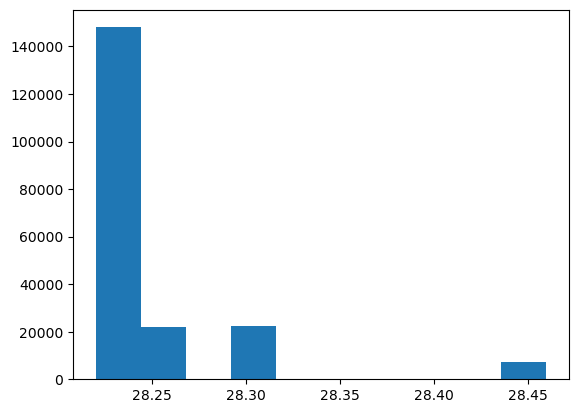

In [177]:
plt.hist(bootstrap_error2(modulus = G1_m,error = G1_e,N=200000,mode=3))


In [ ]:
S.info()

Filename: modulus_tracker.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (1, 1)   float64   
  1  IC0010        1 BinTableHDU     58   1R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  2  IC0010        1 BinTableHDU     34   13R x 10C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A]   
  3  IC2574        1 BinTableHDU     58   0R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  4  IC2574        1 BinTableHDU     34   5R x 10C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A]   
  5  M33           1 BinTableHDU     58   14R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  6  M33           1 BinTableHDU     34   15R x 10C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A]   
  7  M81           1 BinTableHDU     58   15R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  8  M81           1 BinTableHDU     34   9R x 10C   [40A, 40

In [ ]:
S = fits.open('modulus_tracker.fits')

gal_host = 34

P = Table.read(S[gal_host])

print(S[gal_host].header['EXTNAME'],' - ',S[gal_host].header['METHOD'])

P

NGC6822  -  TRGB


RefCode,Citation,Band,mu_0,e_R,Rank,Year,Date,Comments,Author
str40,str40,str40,float64,float64,int64,int64,str12,str800,str50
2000ApJ...529..745F,Ferrarese et al.2000,I(BVI),23.39,0.16,1,2000,2024,na,Valencia et al.2024
2005A&A...429..837C,"Cioni, M.-R. & Habing, H. J. 2005",I(JK),23.34,0.12,2,2005,2024,na,Valencia et al.2024
2011AJ....141..194G,Gorski et al.2011,J(JK),23.31,0.05,2,2011,2024,1,Valencia et al.2024
2011AJ....141..194G,Gorski et al.2011,K(JK),23.26,0.07,2,2011,2024,2,Valencia et al.2024
2012A&A...540A..49M,"McCall, M. L. et al.2012",I(VI),23.32,0.1,2,2012,2024,3,Valencia et al.2024
